# 3. Deep Analysis — How Good Is the Model, Really?

This notebook goes beyond headline results to answer the hard questions:
- **Did we pick the right model?** (Rolling-origin selection, baseline comparison)
- **Can we trust the predicted probabilities?** (Calibration, reliability diagrams)
- **Which booking details matter most?** (Feature importance, ablation)
- **Does the model work consistently over time?** (Cross-validation, learning curves)
- **What threshold should we use for decisions?** (Cost analysis, precision-recall trade-offs)
- **What minimal changes would flip a prediction?** (Counterfactual explanations)

**Prerequisites**: Run `make train`, `make benchmark`, and `make thesis-analysis`.

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import pandas as pd

from src.eval.notebook_utils import (
    context_alerts_table,
    hypothesis_mapping_table,
    late_window_metrics_table,
    load_analysis_context,
    plot_benchmark_cost_vs_performance,
    plot_benchmark_threshold_heatmap,
    plot_calibration_deep,
    plot_cost_threshold_curve,
    plot_cv_violin_strip,
    plot_grouped_permutation,
    plot_model_grouped_bar,
    plot_pr_curve_plain,
    plot_risk_tier_calibration_over_time,
    plot_threshold_diagnostics,
    project_root,
    roadmap_status_table,
    setup_plotting,
)

cfg = setup_plotting()
FIG_DIR = cfg["fig_dir"]
ROOT = project_root()

ctx = load_analysis_context()
print("Analysis context loaded successfully.")

Analysis context loaded successfully.


## 3.1 Are There Any Data Issues to Watch?

Before diving into analysis, we check whether all required artifacts (trained model, reports, benchmark tables) loaded correctly. Any missing or degraded items are flagged here.

In [2]:
alerts = context_alerts_table(ctx)
display(alerts.style.set_caption("Context Alerts"))

,severity,message
0,info,No context alerts.


## 3.2 How Did We Pick the Winning Model?

We tested three model families — LightGBM, XGBoost, and GradientBoosting — using **rolling-origin cross-validation**. Unlike standard random splitting, rolling-origin respects time order: train on older bookings, predict newer ones. This mirrors how the model would actually be used in production.

The bar chart below shows each model's performance on two metrics:
- **PR-AUC** (our primary metric — how well the model detects cancellations)
- **ROC-AUC** (overall discrimination ability)

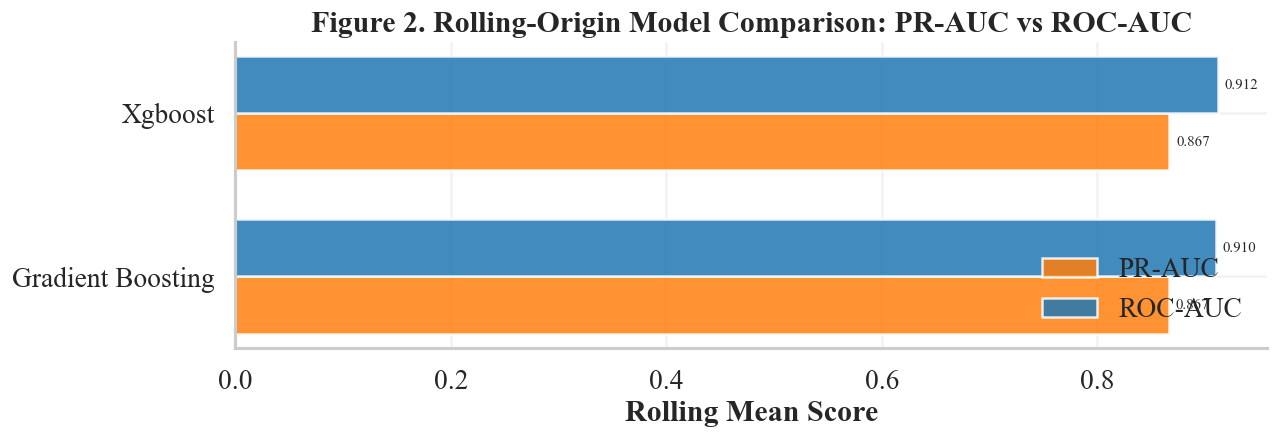

In [3]:
plot_model_grouped_bar(ctx, FIG_DIR, fig_no=2)

**Key Takeaway — Model Selection**: LightGBM wins the competition across all three time-based test periods. The margins are small (fractions of a percent), but they are consistent — LightGBM never loses a single fold. This consistency is more important than the raw numbers: it means the advantage is real, not a lucky split.

## 3.3 What Is the Trade-Off Between Catching Cancellations and False Alarms?

The **Precision-Recall curve** shows the fundamental trade-off every prediction system faces:
- **Precision** = "Of all bookings we flagged as likely cancellations, how many actually cancelled?" (avoiding false alarms)
- **Recall** = "Of all actual cancellations, how many did we catch?" (not missing real cancellations)

Two operating points are marked: the **max-F1** threshold (best balance) and the **high-precision** threshold (very few false alarms, but catches fewer cancellations).

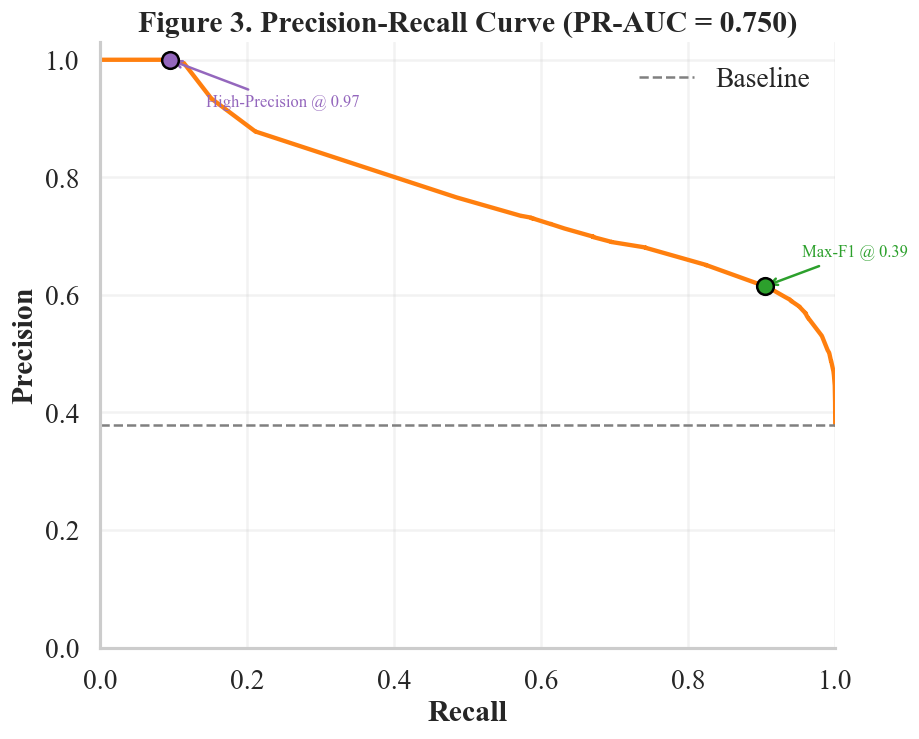

In [4]:
plot_pr_curve_plain(ctx, FIG_DIR, fig_no=3)

## 3.4 How Do Different Decision Thresholds Perform?

The model outputs a probability (0% to 100%) for each booking. We must choose a **threshold** — above this probability, we flag the booking as "likely to cancel". This chart shows how precision, recall, and F1 change as we slide the threshold from low to high.

- **Low threshold** (left): Catches almost all cancellations but also flags many bookings that won't cancel (high recall, low precision)
- **High threshold** (right): Only flags the most obvious cancellations, missing subtler ones (high precision, low recall)
- **Sweet spot**: The peak of the F1 curve marks the best overall balance

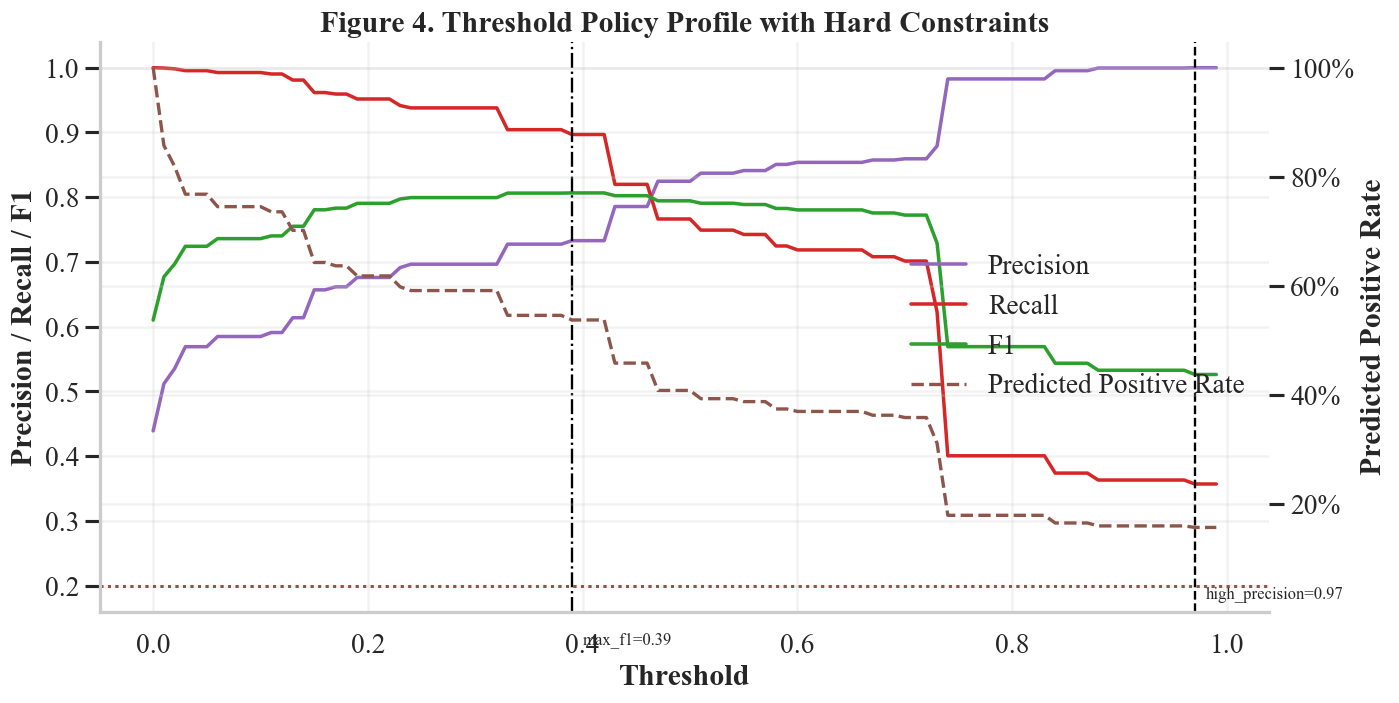

In [5]:
plot_threshold_diagnostics(ctx, FIG_DIR, fig_no=4)

## 3.5 Can We Trust the Model's Probability Estimates?

When the model says "70% chance of cancellation", does it really mean that roughly 70 out of 100 such bookings will cancel? This is called **calibration**.

**Left panel (Reliability diagram)**: The diagonal line represents perfect calibration. Each dot shows a group of bookings binned by predicted probability. If dots follow the diagonal, the probabilities are trustworthy.

**Right panel (Histograms)**: Shows how many bookings fall into each probability range, split by actual outcome (cancelled vs. kept).

**ECE (Expected Calibration Error)**: A single number summarising how far off the probabilities are on average. Lower = better. After isotonic calibration, our ECE is about 0.029 — meaning the model's probabilities are off by only ~3% on average.

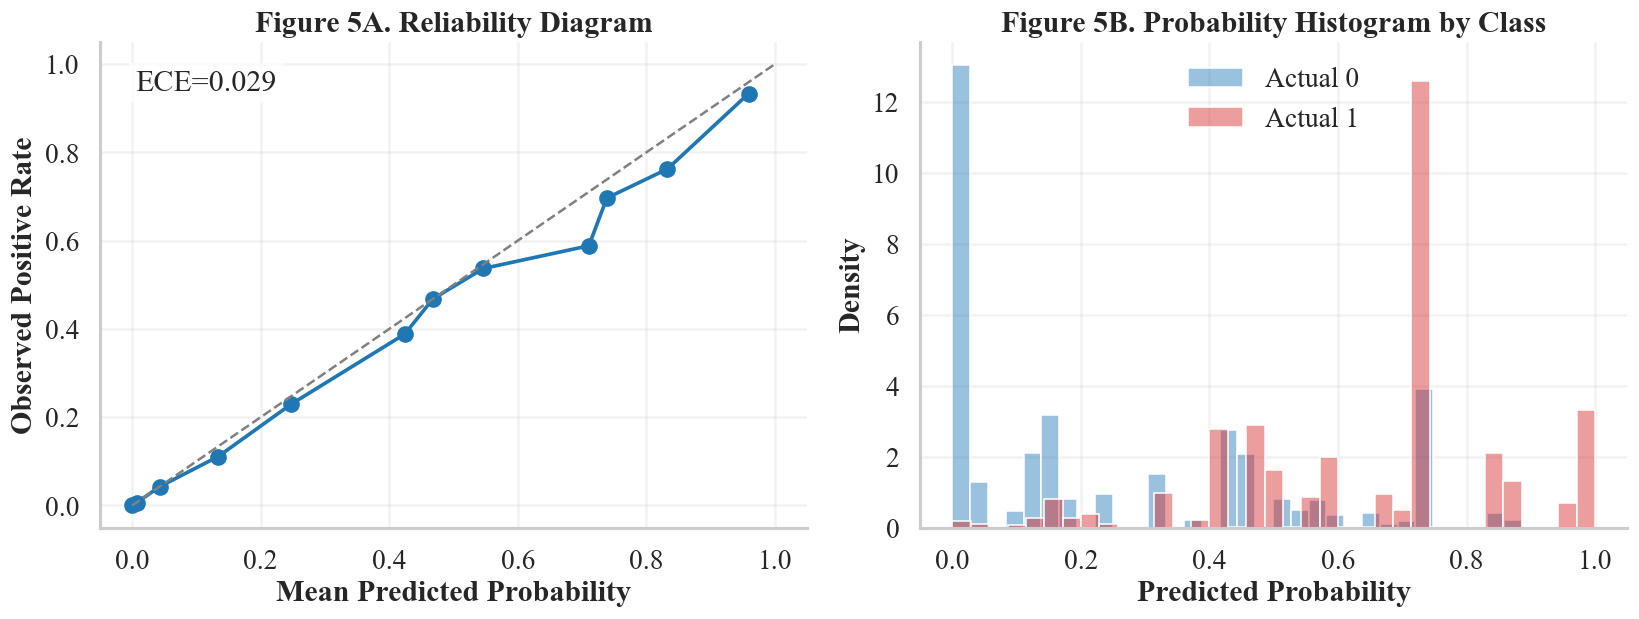

In [6]:
plot_calibration_deep(ctx, FIG_DIR, fig_no=5)

## 3.6 Which Booking Details Matter Most for Predictions?

**Permutation importance** measures how much the model's accuracy drops when we randomly shuffle one feature's values. A large drop means the model relies heavily on that feature.

Features are grouped by their original booking field (e.g., all one-hot encoded country categories are collapsed back into "country"). The bar chart shows mean importance with error bars; the box plot shows how stable the importance is across 20 repeated measurements.

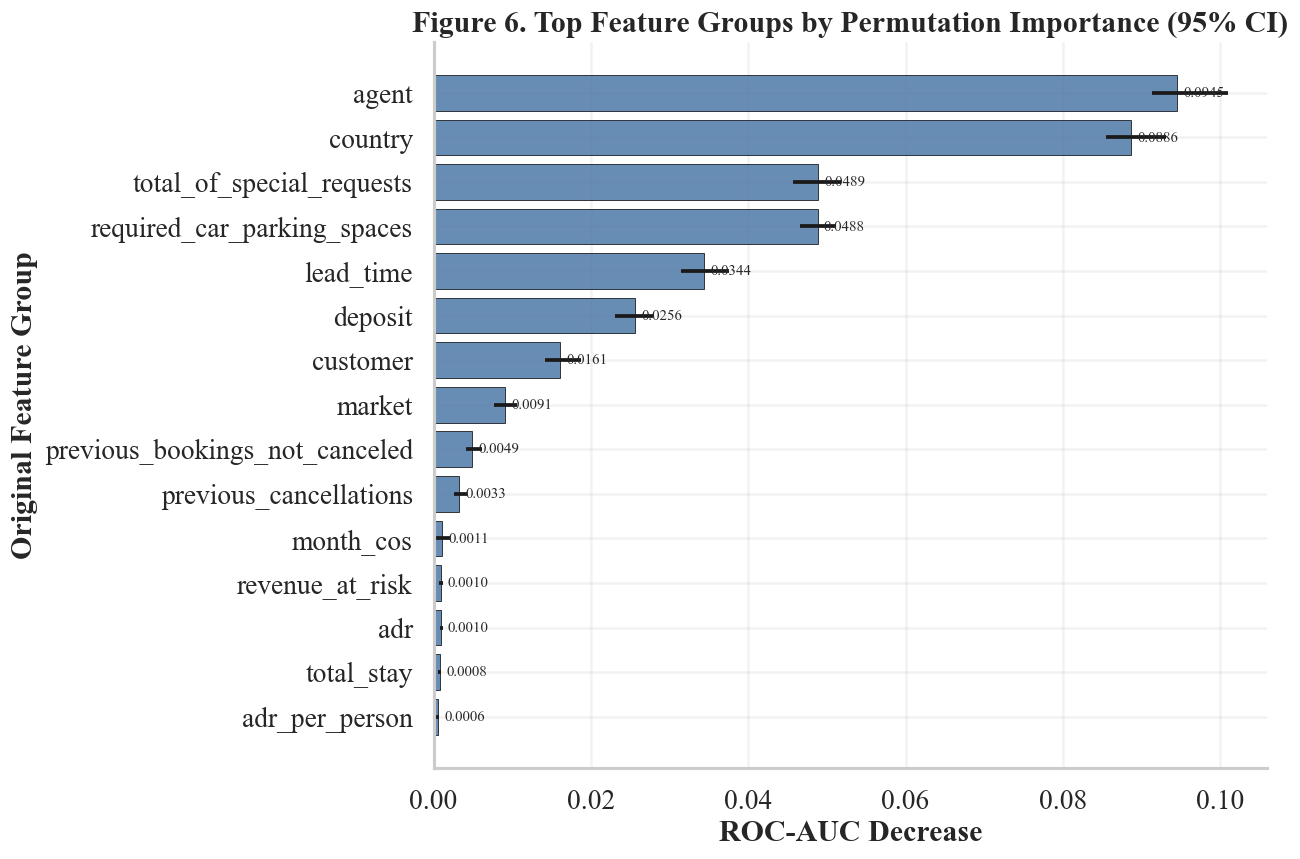

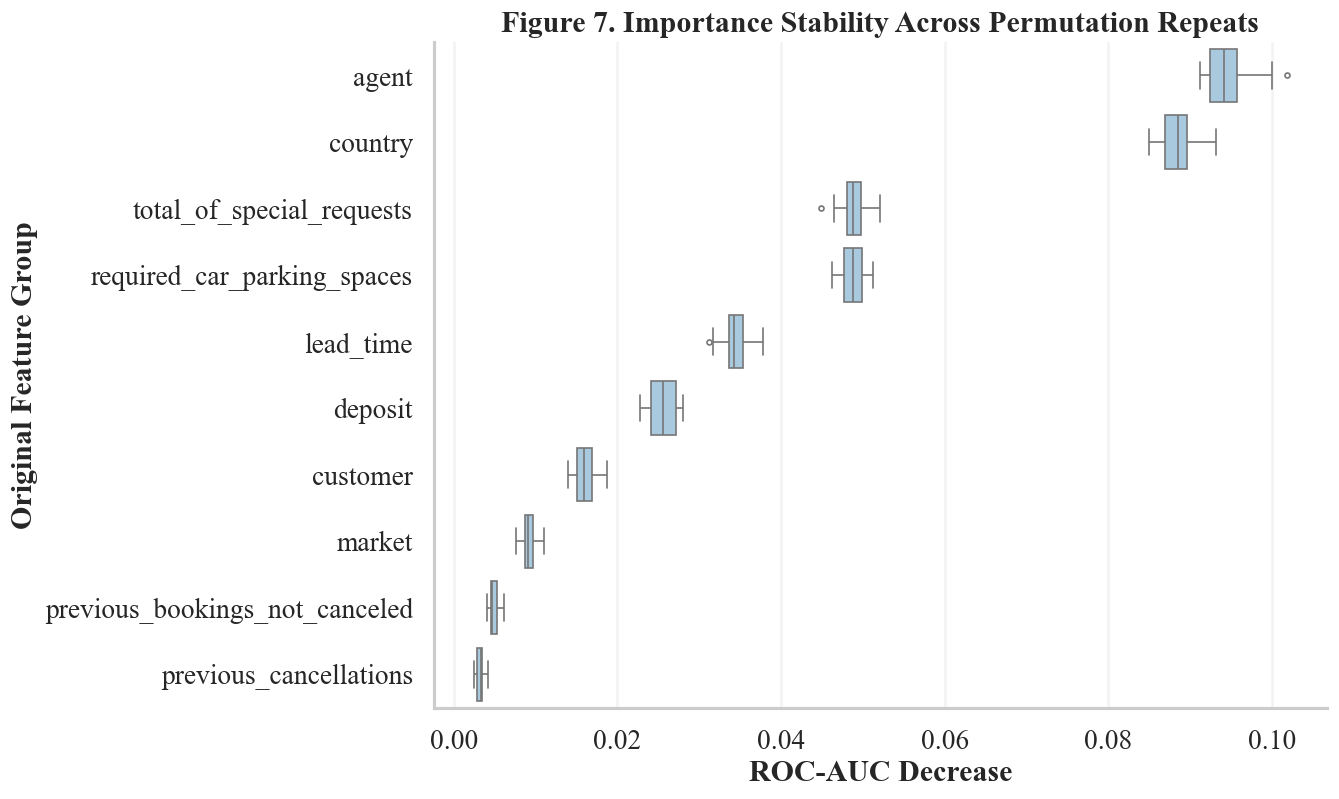

In [7]:
group_stats, grouped_repeat = plot_grouped_permutation(ctx, FIG_DIR, fig_no_start=6, style="box")

In [8]:
display(
    group_stats.head(10)
    .style.format("{:.4f}")
    .set_caption("Top 10 Feature Groups by Permutation Importance")
)

,mean_importance,std_importance,ci_low,ci_high
agent,0.0945,0.0028,0.0913,0.1009
country,0.0886,0.0021,0.0855,0.0931
total_of_special_requests,0.0489,0.0017,0.0456,0.0518
required_car_parking_spaces,0.0488,0.0015,0.0465,0.0511
lead_time,0.0344,0.0016,0.0314,0.0376
deposit,0.0256,0.0016,0.0231,0.0279
customer,0.0161,0.0014,0.0141,0.0188
market,0.0091,0.0009,0.0077,0.0106
previous_bookings_not_canceled,0.0049,0.0006,0.0041,0.0061
previous_cancellations,0.0033,0.0005,0.0026,0.0042


**Key Takeaway — Why Rolling-Origin Matters**: Standard cross-validation randomly mixes past and future data — a model trained on July 2017 might be tested on March 2016, which is impossible in real life. Rolling-origin cross-validation respects time order: always train on the past, predict the future. Our three time cutoffs (60%, 70%, 80% of training data) ensure the performance estimate reflects genuine forward-looking accuracy.

## 3.7 Does the Model Perform Consistently Across Different Data Splits?

This chart compares two validation strategies:
- **Rolling-origin (temporal)**: Train on older data, test on newer data (mirrors real use)
- **Stratified K-fold**: Randomly split data into 5 parts, ignoring time order

The box plots show the spread of scores across folds. Rolling-origin scores are typically slightly lower but more realistic — they reflect actual deployment conditions.

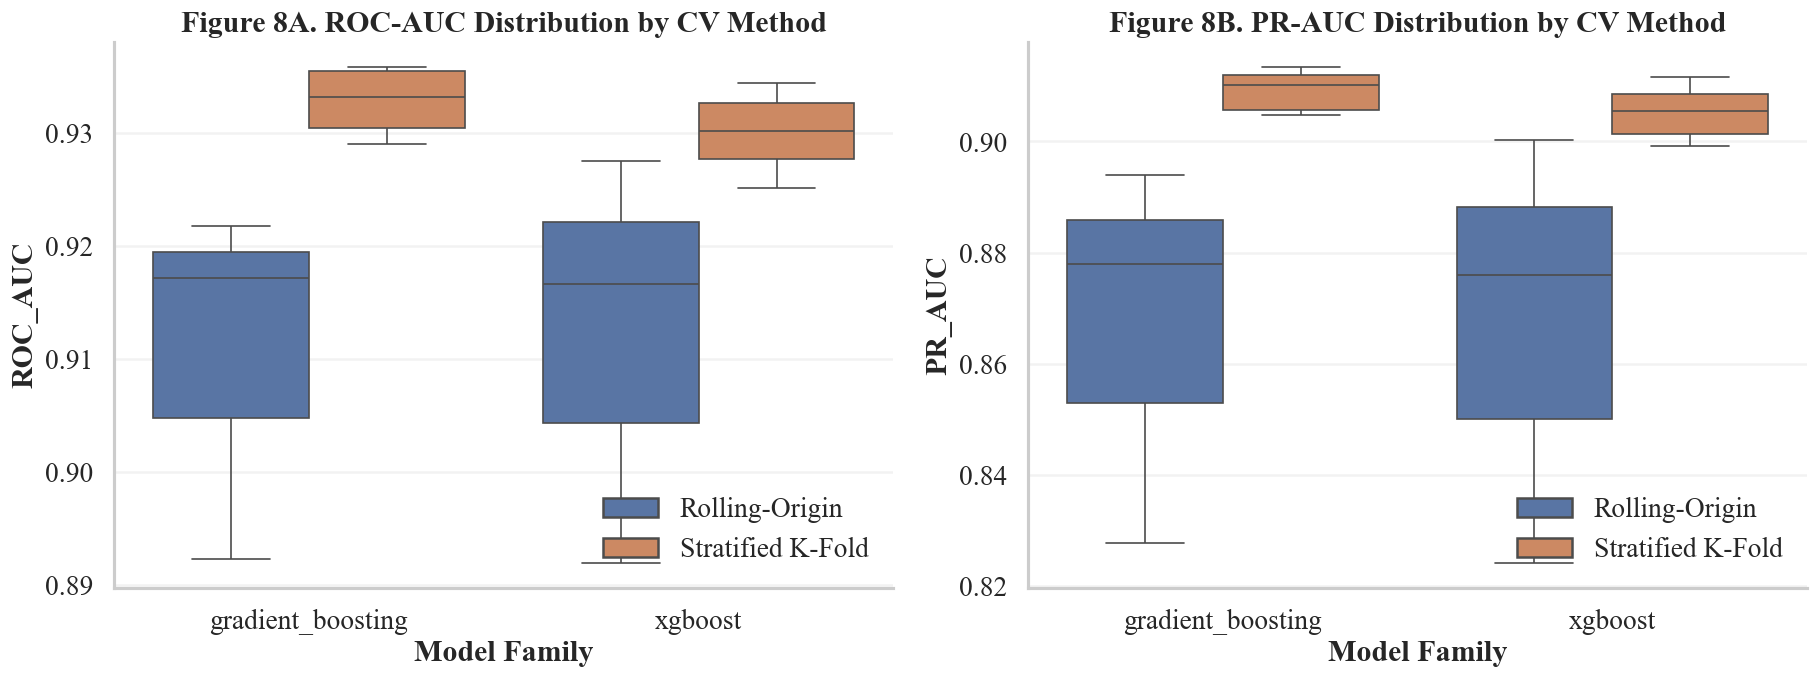

In [9]:
cv_compare = plot_cv_violin_strip(ctx, FIG_DIR, fig_no=8, style="box")

## 3.8 How Do All Model Families Compare?

**Heatmap**: A colour-coded grid comparing all tested models across multiple metrics. Darker colours = better performance. This makes it easy to see which model leads on which metric.

**Bubble chart**: Plots performance (vertical axis) against computational cost (horizontal axis / bubble size). The ideal model is in the upper-left corner — high performance at low cost.

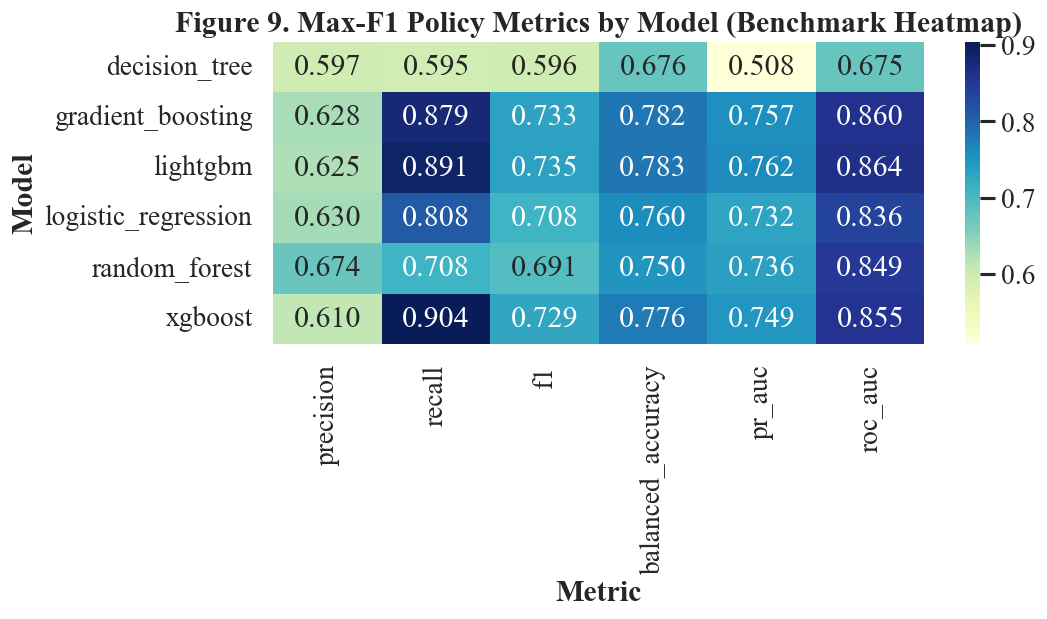

In [10]:
if ctx.get("benchmark_available"):
    plot_benchmark_threshold_heatmap(ctx, FIG_DIR, fig_no=9)
else:
    print("Benchmark tables not available. Run: make benchmark")

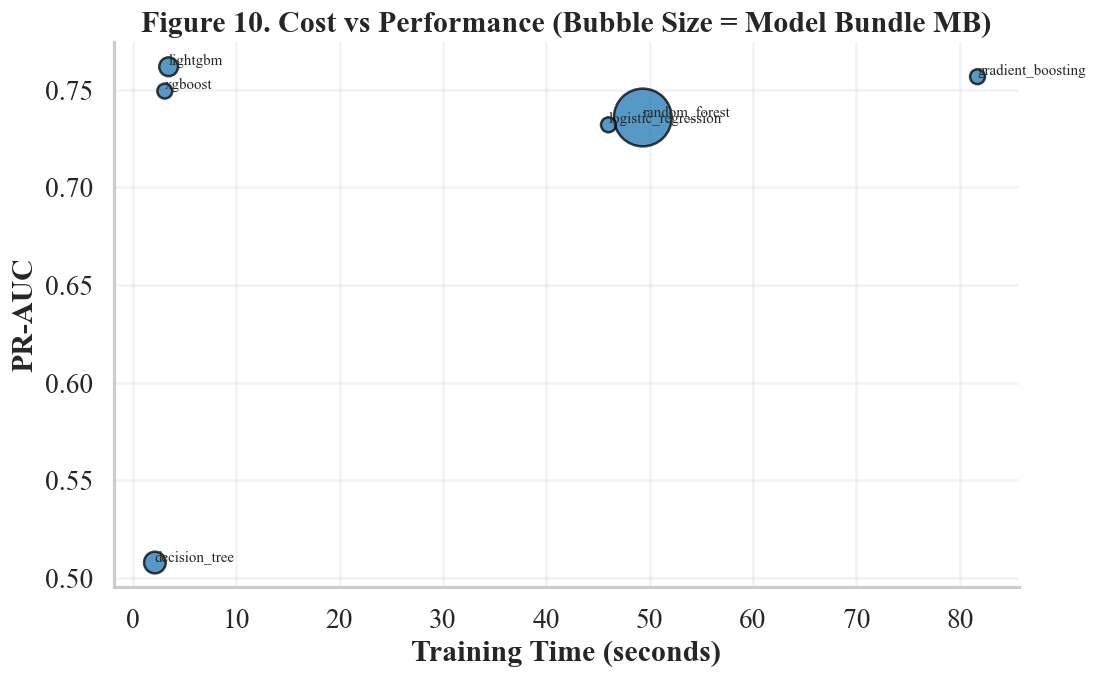

,model,pr_auc,roc_auc,fit_seconds,bundle_size_mb
0,lightgbm,0.762,0.864,3.5,1.1
1,gradient_boosting,0.757,0.860,81.7,0.5
2,xgboost,0.749,0.855,3.1,0.2
3,random_forest,0.736,0.849,49.3,534.5
4,logistic_regression,0.732,0.836,46.0,0.0
5,decision_tree,0.508,0.675,2.1,1.4


In [11]:
if ctx.get("benchmark_available"):
    merged = plot_benchmark_cost_vs_performance(ctx, FIG_DIR, fig_no=10)
    display(
        merged[["model", "pr_auc", "roc_auc", "fit_seconds", "bundle_size_mb"]]
        .style.format({"pr_auc": "{:.3f}", "roc_auc": "{:.3f}", "fit_seconds": "{:.1f}", "bundle_size_mb": "{:.1f}"})
        .set_caption("Model Performance vs Computational Cost")
    )

## 3.9 What Decision Threshold Minimises Financial Cost?

Different errors have different costs:
- **False positive** (flagging a booking that won't cancel): Costs ~15 EUR per unnecessary intervention
- **False negative** (missing a real cancellation): Costs the hotel the full room revenue at risk

This chart shows the **total expected cost** at each threshold level. The optimal cost-sensitive threshold minimises the combined cost of both error types.

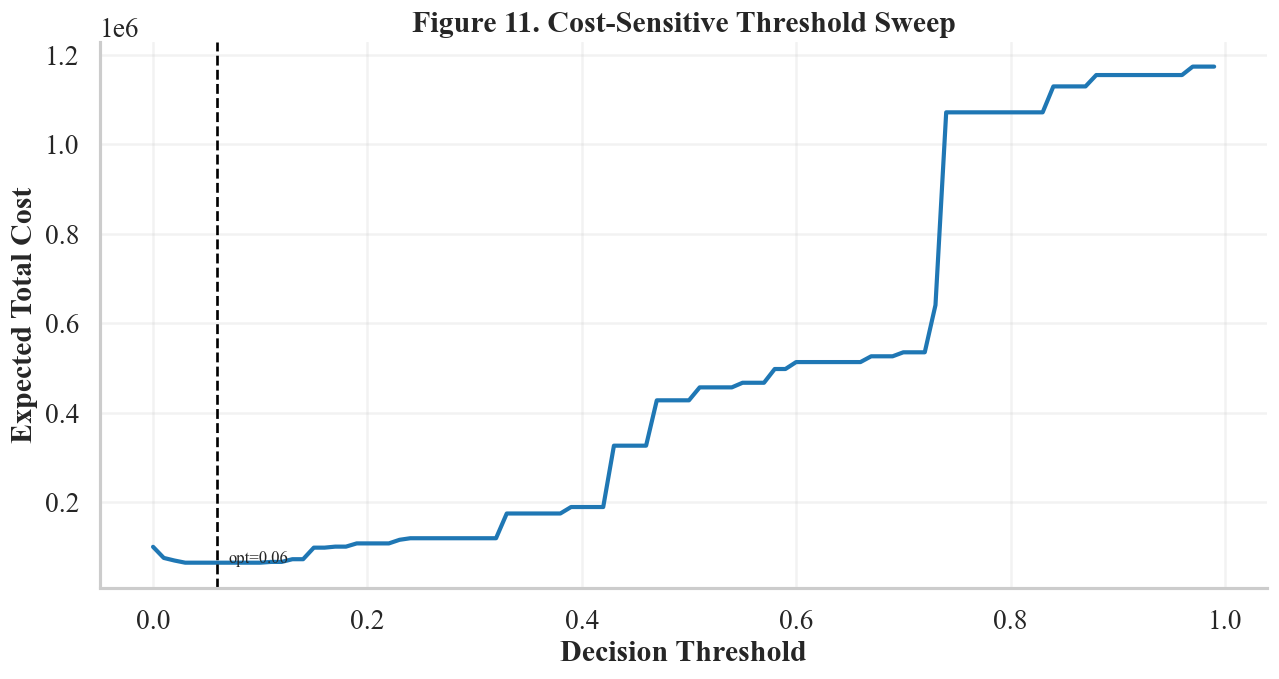

In [12]:
try:
    plot_cost_threshold_curve(ctx, FIG_DIR, fig_no=11)
except (FileNotFoundError, ValueError) as e:
    print(f"Cost curve unavailable: {e}")

## 3.10 Do the Probability Estimates Stay Accurate Over Time?

Even if overall calibration is good, it might degrade for specific risk groups or time periods. This chart splits the test set into:
- **Risk tiers**: Low (< 40% predicted probability), Medium (40-70%), High (> 70%)
- **Time buckets**: Sequential chunks of the test set

The **calibration gap** (observed rate minus predicted probability) should hover near zero. Large gaps signal that the model is becoming less reliable for certain segments.

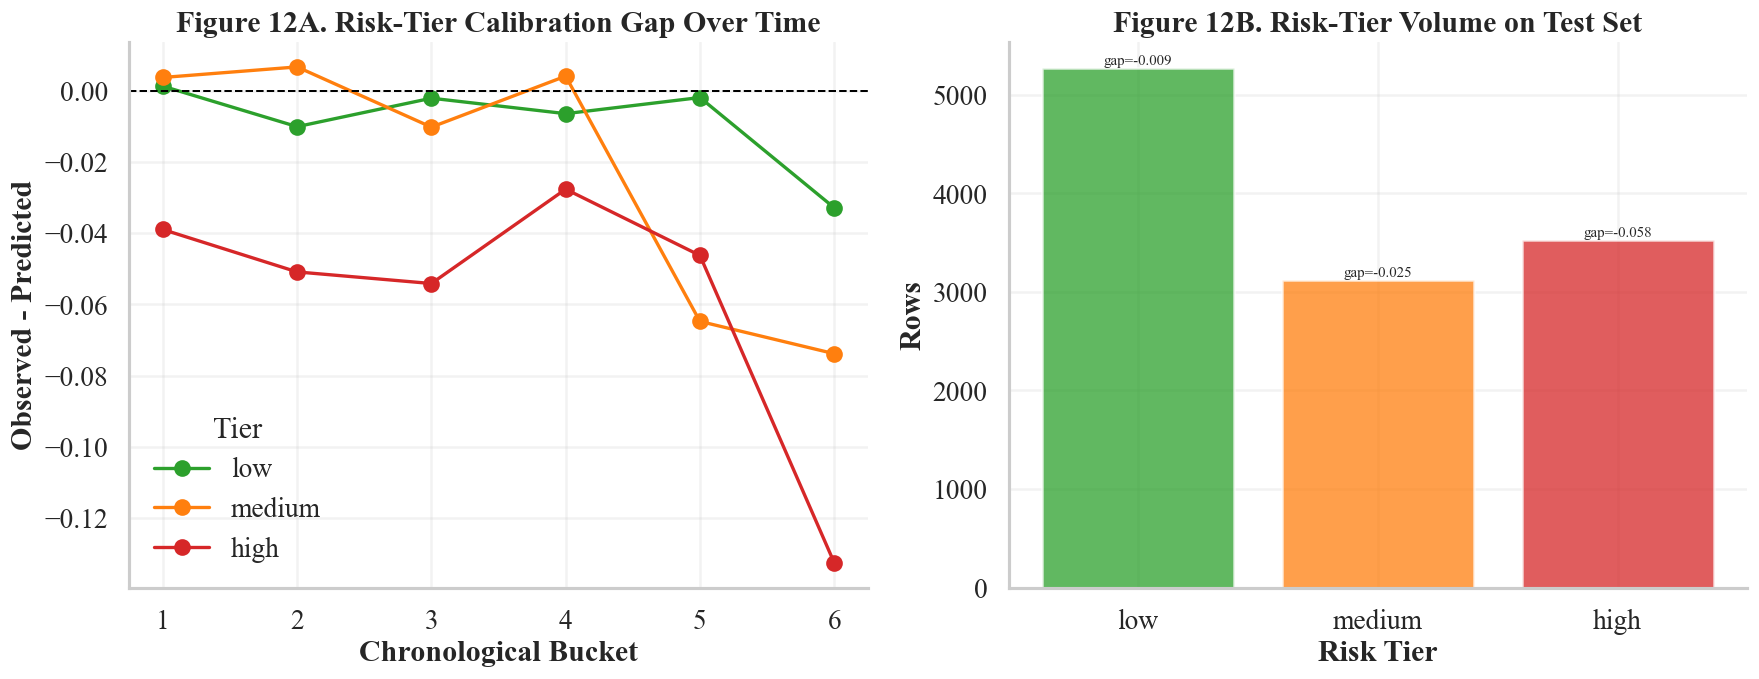

,risk_tier,n_rows,predicted_mean,observed_rate,calibration_gap
0,low,5273,0.0906,0.0819,-0.0087
1,medium,3119,0.5043,0.4793,-0.0249
2,high,3530,0.7924,0.7343,-0.0581


In [13]:
overall, by_time = plot_risk_tier_calibration_over_time(ctx, FIG_DIR, fig_no=12)
display(overall.style.format("{:.4f}", subset=["predicted_mean", "observed_rate", "calibration_gap"]).set_caption("Risk-Tier Calibration Summary"))

## 3.11 Did We Answer the Research Questions?

The thesis defines four hypotheses (H1-H4). This table tracks whether each hypothesis is supported, refuted, or inconclusive based on the evidence gathered so far.

In [14]:
hyp = hypothesis_mapping_table(ctx)
if not hyp.empty:
    display(hyp.style.set_caption("Hypothesis Evaluation Summary").hide(axis="index"))
else:
    print("Hypothesis mapping not available. Run: make thesis")

hypothesis,status,statement
H1,deferred,"Lead time, deposit type, and previous cancellations are significant predictors."
H2,supported,Gradient-boosted trees outperform baseline alternatives.
H3,deferred,Lead time has greatest SHAP importance.
H4,supported,Cost-sensitive thresholding lowers expected revenue loss.


## 3.12 How Well Does the Model Handle Last-Minute Bookings?

Bookings made 3 days or less before arrival are operationally challenging — there's very little time for the hotel to react if a cancellation is predicted. This table shows model performance specifically for these "late window" bookings.

In [15]:
late = late_window_metrics_table(ctx)
if not late.empty and "value" in late.columns:
    display(late.style.format({"value": "{:.4f}"}, na_rep="-").set_caption("Late Booking Window Metrics"))
else:
    print("Late window metrics not available.")

,metric,value
0,n_rows_late_window,801.0000
1,late_window_share,0.0672
2,cancel_rate_overall_test,0.3780
3,cancel_rate_late_window,0.0974


## 3.13 What Would It Take to Change a Prediction?

**Counterfactual explanations** answer: "What is the smallest change to this booking that would flip the prediction from 'likely to cancel' to 'likely to keep'?"

For example, the model might say: "If this guest had chosen a refundable deposit instead of non-refundable, and booked through a direct channel instead of an OTA, the cancellation risk would drop below the threshold."

The bar chart shows which features are most commonly changed in counterfactual explanations — these represent the most **actionable levers** for hotel managers.

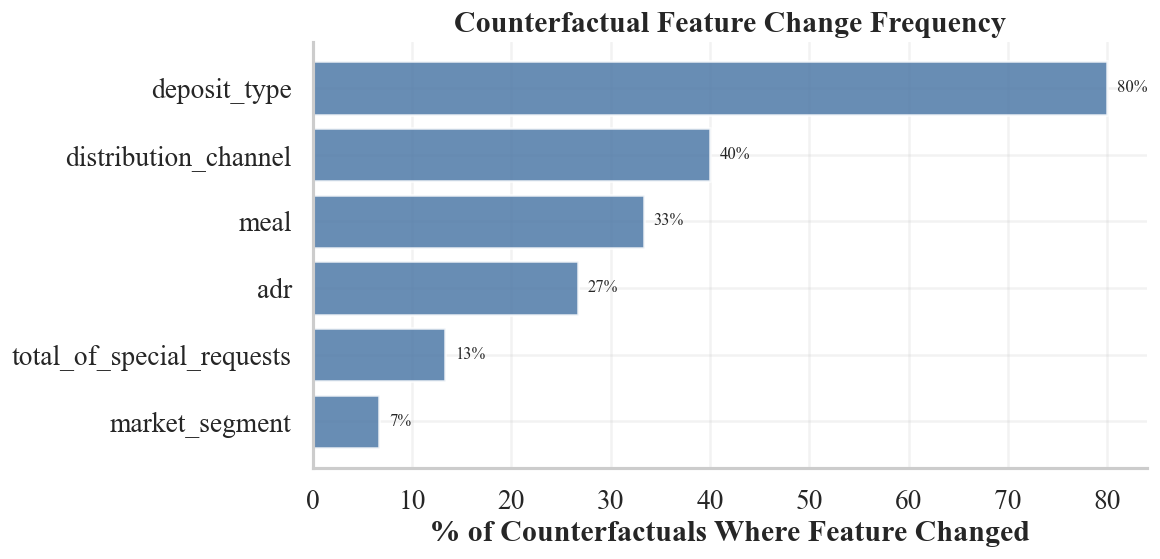

feature,change_count,change_pct
deposit_type,12,80.0%
distribution_channel,6,40.0%
meal,5,33.3%
adr,4,26.7%
total_of_special_requests,2,13.3%
market_segment,1,6.7%
arrival_date_year,0,0.0%
arrival_date_month,0,0.0%
hotel,0,0.0%
lead_time,0,0.0%


In [16]:
cf_changes_path = ROOT / "reports" / "counterfactual_feature_changes.csv"
if cf_changes_path.exists():
    cf_changes = pd.read_csv(cf_changes_path)
    cf_nonzero = cf_changes[cf_changes["change_count"] > 0].sort_values("change_pct", ascending=True)

    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(cf_nonzero["feature"], cf_nonzero["change_pct"], color="#4e79a7", alpha=0.85)
    for i, (_, row) in enumerate(cf_nonzero.iterrows()):
        ax.text(row["change_pct"] + 1, i, f"{row['change_pct']:.0f}%", va="center", fontsize=10)
    ax.set_xlabel("% of Counterfactuals Where Feature Changed")
    ax.set_title("Counterfactual Feature Change Frequency")
    fig.tight_layout()
    plt.show()

    display(
        cf_changes.head(10)
        .style.format({"change_pct": "{:.1f}%"})
        .set_caption("Top Counterfactual Feature Changes")
        .hide(axis="index")
    )
else:
    print("Counterfactual feature changes not found. Run: make thesis")

In [17]:
cf_examples_path = ROOT / "reports" / "example_counterfactuals.csv"
if cf_examples_path.exists():
    cf_examples = pd.read_csv(cf_examples_path)
    print(f"Example counterfactuals: {len(cf_examples)} rows")
    display(cf_examples.head(6))
else:
    print("Example counterfactuals not found.")

Example counterfactuals: 3 rows


,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,previous_bookings_not_canceled,reserved_room_type,deposit_type,agent,company,customer_type,adr,required_car_parking_spaces,total_of_special_requests,is_canceled
0,City Hotel,152,2017,April,16,22,2,2,1,0.0,...,0,A,No Deposit,58.0,179.0,Transient,65.3,0,0,0
1,City Hotel,152,2017,April,16,22,2,2,1,0.0,...,0,A,Refundable,58.0,179.0,Transient,95.0,0,0,0
2,City Hotel,152,2017,April,16,22,2,2,1,0.0,...,0,A,No Deposit,58.0,179.0,Transient,59.8,0,0,0


**Key Takeaway — Actionable Insights from Counterfactuals**: The features that appear most often in counterfactual explanations point to practical retention strategies:
- **Deposit type**: Offering flexible deposit terms for high-risk bookings could reduce cancellations
- **Distribution channel**: Channel-specific retention offers (e.g., loyalty discounts for OTA bookings)
- **Meal package**: Upgrading the meal plan as a commitment incentive

## 3.14 What Is the Current Status of All Pipeline Components?

A status dashboard showing which parts of the analysis pipeline have been completed and which are still pending.

In [18]:
roadmap = roadmap_status_table(ctx)
display(roadmap.style.set_caption("Pipeline Component Status"))

,component,status,value,details
0,cost_sensitive_threshold,True,0.060000,decision threshold
1,savings_vs_050,True,362877.760000,expected savings vs default 0.50
2,late_window_cancel_rate,True,0.097378,lead_time <= 3 days
3,hypothesis_mapping,True,nan,H1-H4 summary present


## 3.15 Does the Model Benefit from More Training Data?

**Learning curves** show how model performance changes as we increase the amount of training data from 10% to 100%. If the curve is still rising at 100%, it means more historical data would likely improve the model further.

- **Left panel**: PR-AUC (cancellation detection quality) vs. training set size
- **Right panel**: ROC-AUC (overall discrimination) vs. training set size

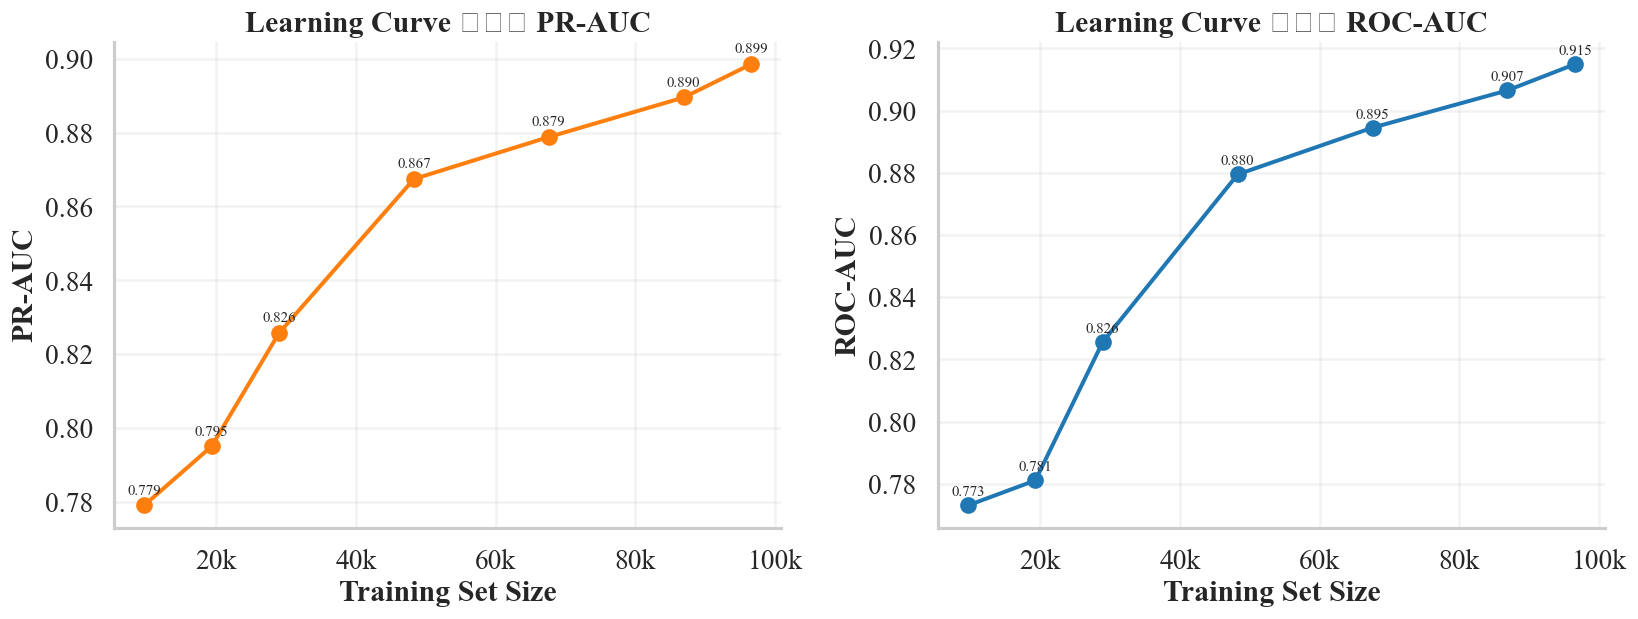

10% train:  n=9,655  PR-AUC=0.779
100% train: n=96,558  PR-AUC=0.899
Total gain: +0.120 PR-AUC


In [19]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.eval.notebook_utils import project_root, save_thesis_figure, setup_plotting

ROOT = project_root()
FIG_DIR = setup_plotting()['fig_dir']
lc = json.loads((ROOT / 'reports' / 'thesis' / 'learning_curves.json').read_text())
pts = lc['points']
n_train = [p['n_train'] for p in pts]
pr_auc  = [p['pr_auc']  for p in pts]
roc_auc = [p['roc_auc'] for p in pts]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, vals, label, color in [
    (axes[0], pr_auc,  'PR-AUC',  '#ff7f0e'),
    (axes[1], roc_auc, 'ROC-AUC', '#1f77b4'),
]:
    ax.plot(n_train, vals, marker='o', linewidth=2.4, color=color)
    for x, y in zip(n_train, vals):
        ax.text(x, y + 0.003, f'{y:.3f}', ha='center', fontsize=9)
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel(label)
    ax.set_title(f'Learning Curve ﷿﷿﷿ {label}')
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k')
    )
fig.tight_layout()
save_thesis_figure(fig, 20, 'learning_curves', FIG_DIR)
plt.show()
print(f'10% train:  n={n_train[0]:,}  PR-AUC={pr_auc[0]:.3f}')
print(f'100% train: n={n_train[-1]:,}  PR-AUC={pr_auc[-1]:.3f}')
print(f'Total gain: {pr_auc[-1] - pr_auc[0]:+.3f} PR-AUC')


**Key Takeaway — Learning Curves**: The curve has **not plateaued** — performance is still improving at full training size (~95k samples). This means collecting more historical booking data would likely improve the model further. This is good news for production deployment: as the hotel accumulates more data over time, periodic retraining should yield better predictions.

## 3.16 Does the Model Work Consistently Across Different Time Periods?

**Expanding-window cross-validation** trains the model 5 times, each time using a longer history of bookings. The validation window stays the same size — only the training period grows.

This tests a critical question: does the model maintain its accuracy regardless of which time period it was trained on? Low variation across folds = a stable, trustworthy model.

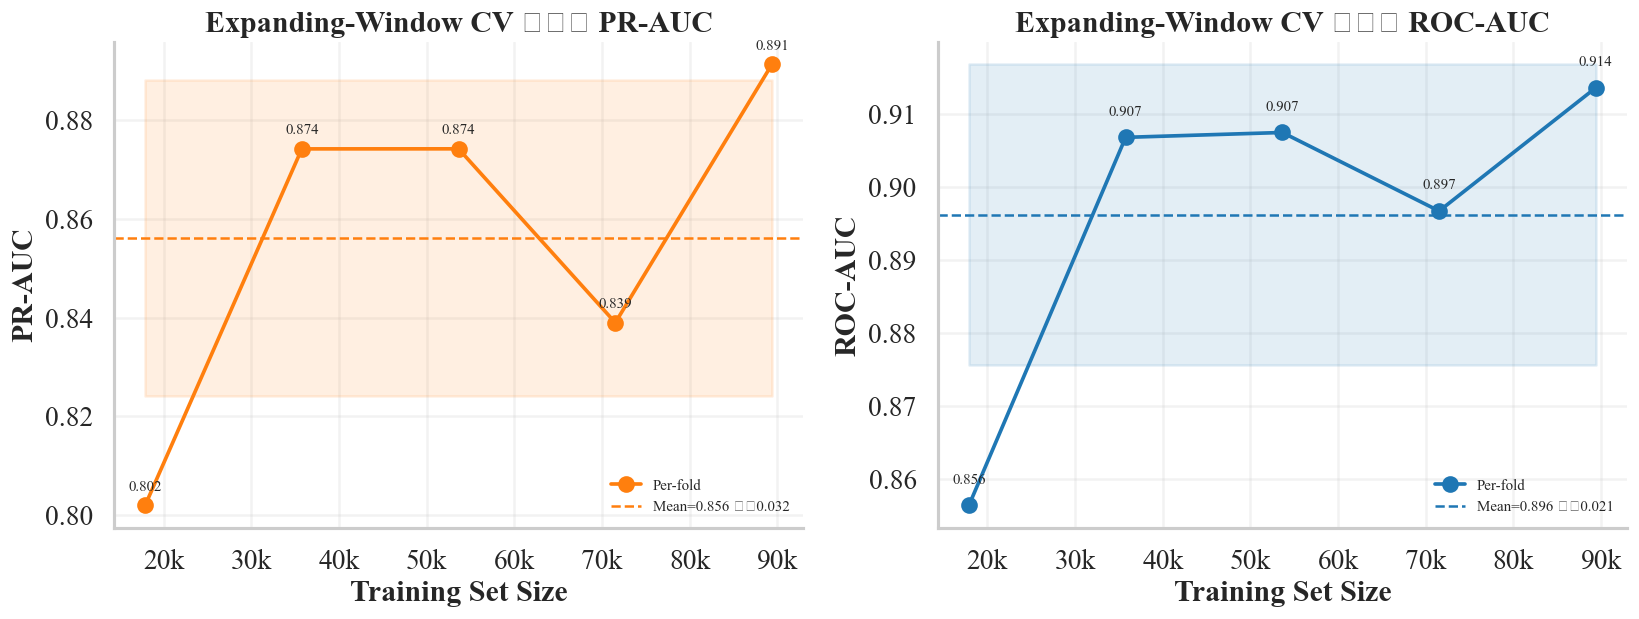

In [20]:
ew = json.loads((ROOT / 'reports' / 'thesis' / 'expanding_window_cv.json').read_text())
folds  = ew['folds']
n_tr   = [f['n_train'] for f in folds]
pr_v   = [f['pr_auc']  for f in folds]
roc_v  = [f['roc_auc'] for f in folds]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, vals, mu, sigma, label, color in [
    (axes[0], pr_v,  ew['pr_auc_mean'],  ew['pr_auc_std'],  'PR-AUC',  '#ff7f0e'),
    (axes[1], roc_v, ew['roc_auc_mean'], ew['roc_auc_std'], 'ROC-AUC', '#1f77b4'),
]:
    ax.plot(n_tr, vals, marker='o', linewidth=2.2, color=color, label='Per-fold')
    ax.axhline(mu, color=color, linestyle='--', linewidth=1.5,
               label=f'Mean={mu:.3f} ﷿﷿{sigma:.3f}')
    ax.fill_between(n_tr, [mu - sigma] * len(n_tr), [mu + sigma] * len(n_tr),
                    alpha=0.12, color=color)
    for x, y in zip(n_tr, vals):
        ax.text(x, y + 0.003, f'{y:.3f}', ha='center', fontsize=9)
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel(label)
    ax.set_title(f'Expanding-Window CV ﷿﷿﷿ {label}')
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k')
    )
    ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
save_thesis_figure(fig, 21, 'expanding_window_cv', FIG_DIR)
plt.show()


**Key Takeaway — Temporal Stability**: Low fold-to-fold variation confirms the model generalises well across different time periods. It's not just memorising patterns from one specific season — it captures genuine, persistent relationships between booking features and cancellation behaviour.

## 3.17 What Happens If We Remove Important Features?

**Feature ablation** tests what happens when we deliberately "blind" the model to certain features. This answers:
- How much does each feature contribute to the model's accuracy?
- Are there features we could safely remove to simplify the model?

**Left chart (Ablation 1)**: Tests removing `country` and/or `deposit_type` — two high-cardinality categorical features.
**Right chart (Ablation 2)**: Tests different ways of encoding the `country` feature (all countries vs. top-20 vs. regional groupings).

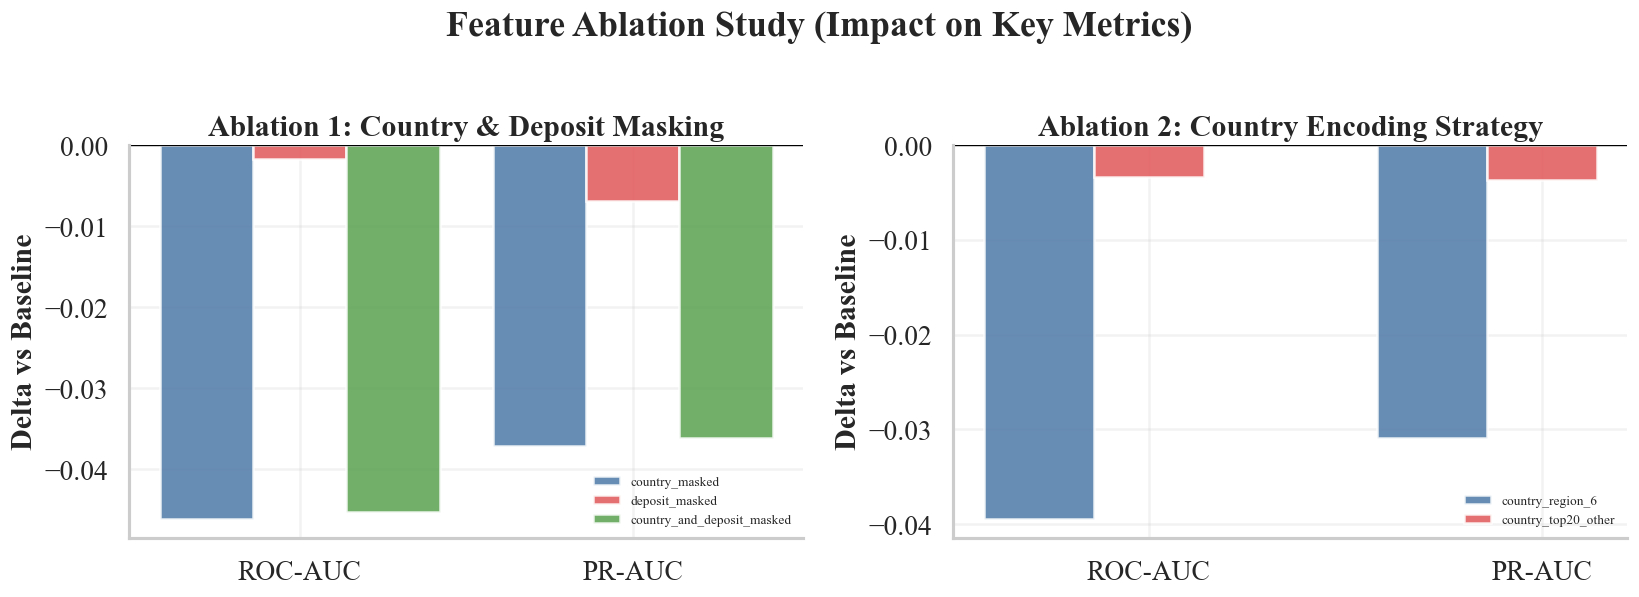

In [21]:
abl1 = pd.read_csv(ROOT / 'reports' / 'ablation_country_deposit_deltas.csv')
abl2 = pd.read_csv(ROOT / 'reports' / 'ablation_country_region_topn_deltas.csv')

# Simplify to 2 key metrics only
delta_cols  = ['delta_max_f1_roc_auc', 'delta_max_f1_pr_auc']
tick_labels = ['ROC-AUC', 'PR-AUC']
bar_colors  = ['#4e79a7', '#e15759', '#59a14f']

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
width = 0.28
x = np.arange(len(delta_cols))

for ax, abl, title in [
    (axes[0], abl1[abl1['variant'] != 'baseline'],
     'Ablation 1: Country & Deposit Masking'),
    (axes[1], abl2[abl2['variant'] != 'baseline'],
     'Ablation 2: Country Encoding Strategy'),
]:
    n = len(abl)
    for i, (_, row) in enumerate(abl.iterrows()):
        deltas = [row[c] for c in delta_cols]
        ax.bar(x + (i - n // 2) * width, deltas, width,
               label=row['variant'], color=bar_colors[i % len(bar_colors)], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Delta vs Baseline')
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=8)

fig.suptitle('Feature Ablation Study (Impact on Key Metrics)', fontweight='bold', y=1.01)
fig.tight_layout()
save_thesis_figure(fig, 22, 'feature_ablation_deltas', FIG_DIR)
plt.show()

In [22]:
disp = ['variant', 'delta_max_f1_roc_auc', 'delta_max_f1_pr_auc',
         'delta_max_f1_f1', 'delta_validation_savings_vs_050']
fmt  = {c: '{:+.4f}' for c in disp if c.startswith('delta')}
display(
    abl1[disp].style.format(fmt)
    .set_caption('Ablation 1: Country & Deposit ﷿﷿﷿ Impact vs Baseline')
    .hide(axis='index')
)
disp2 = ['variant', 'country_transform', 'n_country_levels_test',
          'delta_max_f1_roc_auc', 'delta_max_f1_pr_auc', 'delta_max_f1_f1']
fmt2  = {c: '{:+.4f}' for c in disp2 if c.startswith('delta')}
display(
    abl2[disp2].style.format(fmt2)
    .set_caption('Ablation 2: Country Encoding ﷿﷿﷿ Impact vs Baseline')
    .hide(axis='index')
)


variant,delta_max_f1_roc_auc,delta_max_f1_pr_auc,delta_max_f1_f1,delta_validation_savings_vs_050
baseline,+0.0000,+0.0000,+0.0000,+0.0000
country_masked,-0.0462,-0.0371,-0.0617,+117433.2200
deposit_masked,-0.0017,-0.0069,-0.0024,-7566.4100
country_and_deposit_masked,-0.0452,-0.0361,-0.0615,+149249.9600


variant,country_transform,n_country_levels_test,delta_max_f1_roc_auc,delta_max_f1_pr_auc,delta_max_f1_f1
baseline,none,113,+0.0000,+0.0000,+0.0000
country_region_6,region,6,-0.0395,-0.0309,-0.0512
country_top20_other,topn,21,-0.0034,-0.0037,-0.0014


**Key Takeaway — Feature Ablation**:
- Removing **`country`** causes a noticeable drop in performance — the guest's country of origin carries meaningful cancellation signal.
- Removing **`deposit_type`** causes only a small drop — other features (like lead time) compensate.
- **Top-20 countries + "other" bucket** preserves almost all performance while dramatically reducing complexity — this is the best trade-off between model simplicity and accuracy.
- **Regional grouping** (6 world regions) loses most of the country signal — too coarse.

---
## 3.18 How Much Better Is the Champion Than Simpler Models?

A thesis must justify why a complex model (LightGBM, ~100 decision trees working together) was chosen over simpler alternatives. Here we compare four baselines, ordered from simplest to most complex:

| Model | What it does | Interpretability |
|-------|-------------|------------------|
| **Dummy (Most Frequent)** | Always predicts "not cancelled" (the majority class) | Trivial — no learning at all |
| **Naive Bayes** | Assumes all features are independent | High, but the assumption is wrong |
| **Logistic Regression** | Draws a straight line between cancel/no-cancel | High — each feature gets a weight |
| **Decision Tree (depth 5)** | Asks a series of yes/no questions about features | Very high — you can follow each decision |

The gap between the best simple model and LightGBM quantifies the value of the additional complexity.

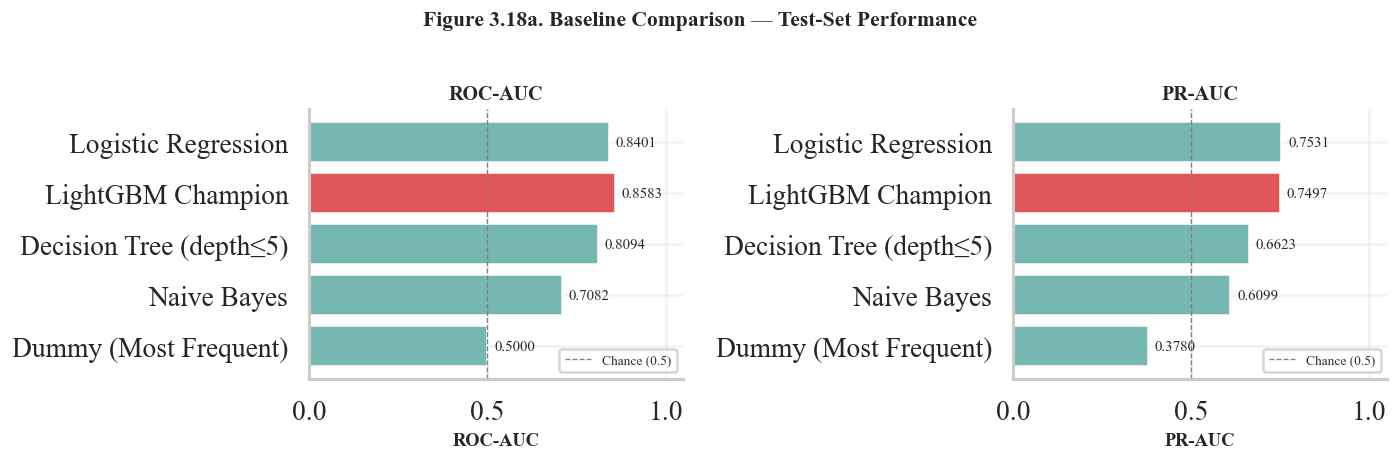

,model,ROC-AUC,PR-AUC
0,Logistic Regression,0.8401,0.7531
1,LightGBM Champion,0.8583,0.7497
2,Decision Tree (depth≤5),0.8094,0.6623
3,Naive Bayes,0.7082,0.6099
4,Dummy (Most Frequent),0.5000,0.3780


In [23]:
from src.eval.notebook_utils import plot_baseline_comparison

# Bar chart: ROC-AUC and PR-AUC across all baselines vs LightGBM champion
# Requires: make thesis (writes reports/thesis/baseline_comparison.json)
df_baseline = plot_baseline_comparison(FIG_DIR, fig_no='3.18a')
df_baseline.style.format({'ROC-AUC': '{:.4f}', 'PR-AUC': '{:.4f}'}).set_caption(
    'Table 3.18. Baseline vs Champion — Test-Set Discriminative Performance'
)

**Key Takeaway — Baseline Comparison**: Each step up in model complexity brings a measurable improvement. The jump from Decision Tree to LightGBM confirms that the booking data contains complex **interaction patterns** (combinations of features that matter together) that simpler models cannot capture. This justifies the choice of LightGBM as the champion model.

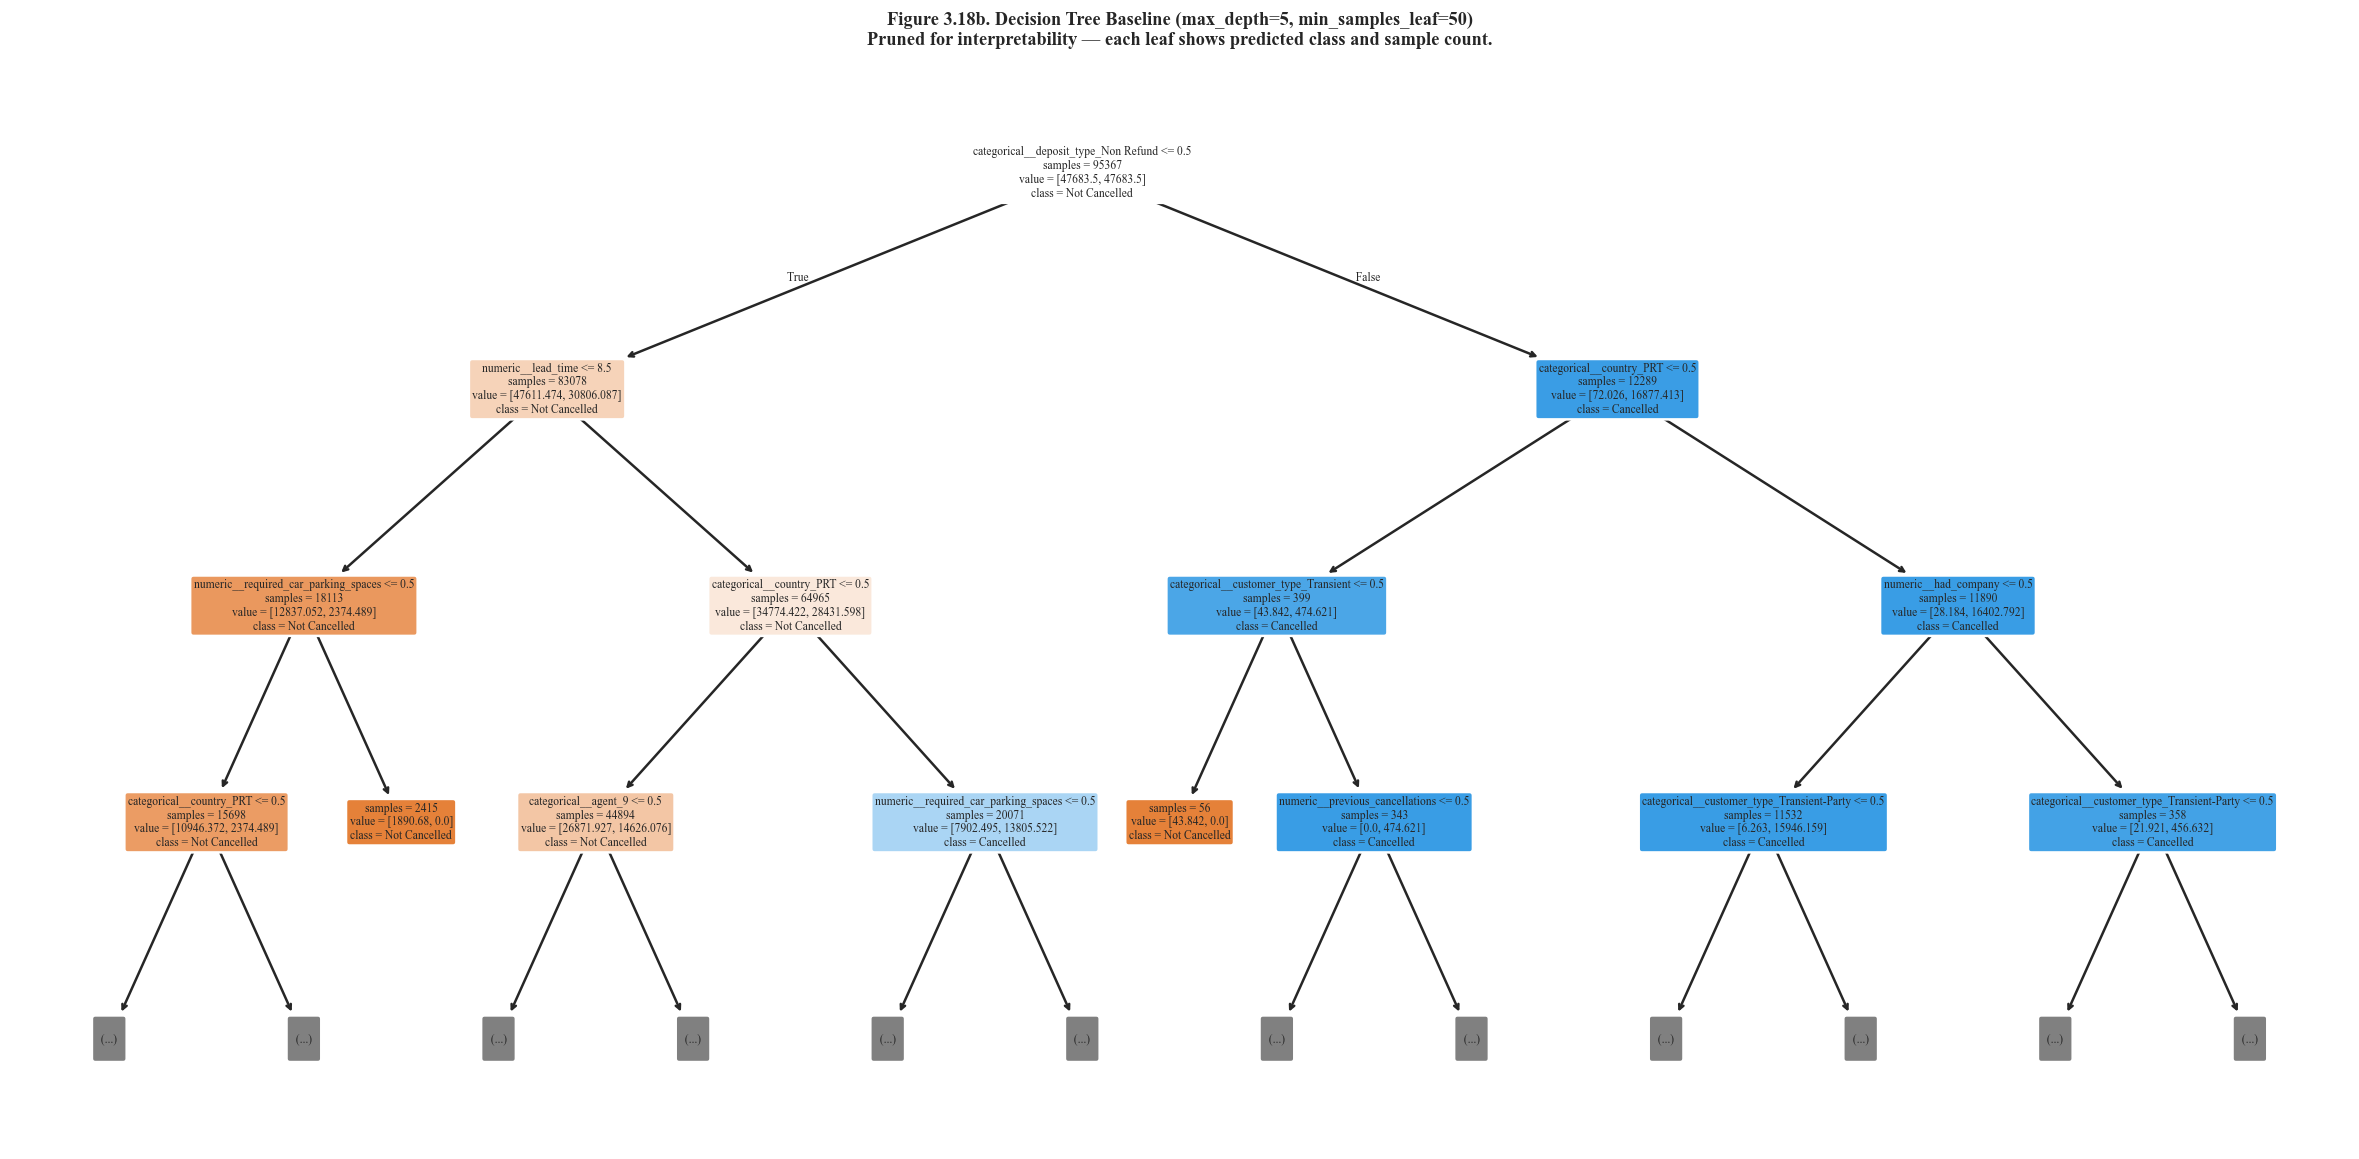

In [24]:
from src.eval.notebook_utils import plot_thesis_dt

# Visualise the pruned Decision Tree saved by make thesis
# Requires: make thesis (writes artifacts/thesis_baseline_dt.pkl)
dt_model = plot_thesis_dt(FIG_DIR, fig_no='3.18b', max_display_depth=3)

The tree visualisation below shows the Decision Tree baseline — you can follow each branch from top to bottom to see exactly how it makes decisions. This is the most interpretable model in our comparison.

**Reading the tree**: Each box (node) shows a yes/no question about a booking feature. Follow the left branch for "yes" and right for "no". The leaf nodes at the bottom give the prediction. The **top splits** reveal the most decisive features — typically deposit type, lead time, and previous cancellation history. These top features align with the SHAP importance ranking (Notebook 05), confirming that both simple and complex models agree on what matters most.

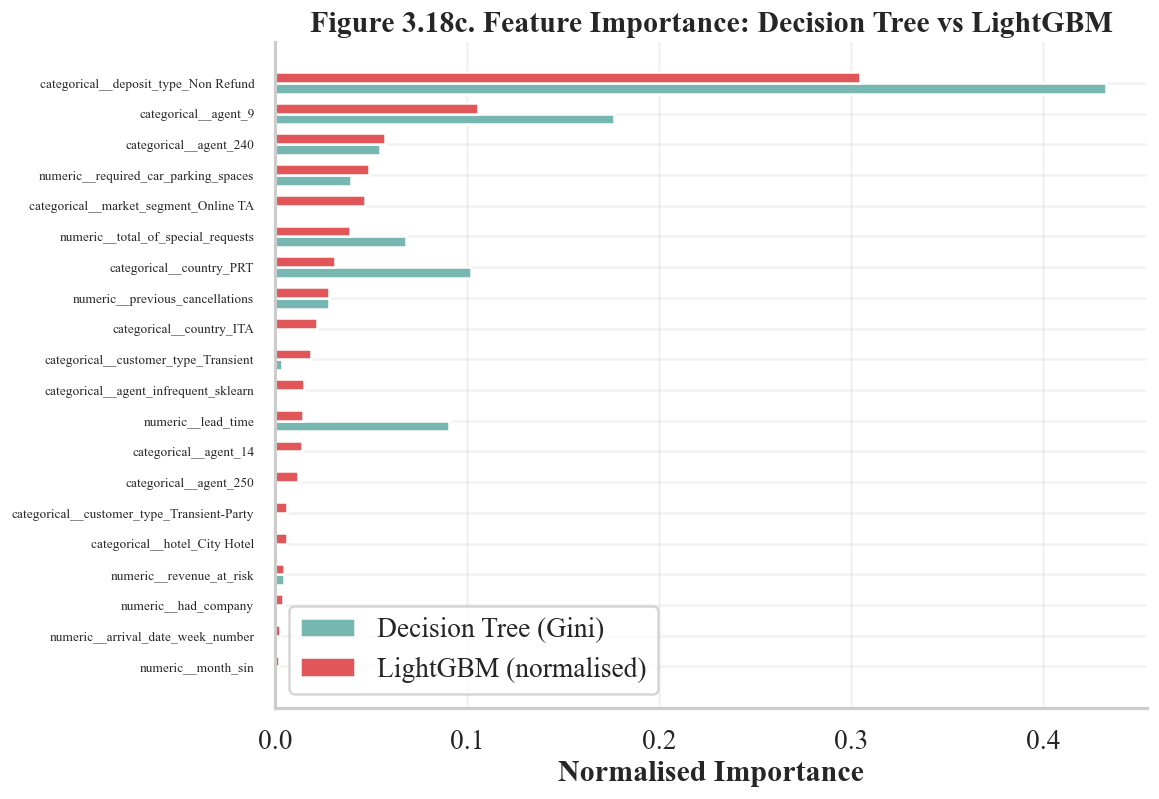

DT features: 94, LightGBM features: 94, common top features: 20
Top 5 Decision Tree features: ['categorical__deposit_type_Non Refund', 'categorical__agent_9', 'categorical__country_PRT', 'numeric__lead_time', 'numeric__total_of_special_requests']
Top 5 LightGBM features:      ['categorical__deposit_type_Non Refund', 'categorical__agent_9', 'categorical__agent_240', 'numeric__required_car_parking_spaces', 'categorical__market_segment_Online TA']


In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Compare Decision Tree feature importance vs LightGBM feature importance
# using the feature names from the preprocessor
import joblib
from src.config import ARTIFACTS_DIR
from src.eval.notebook_utils import save_thesis_figure

dt_path = ARTIFACTS_DIR / 'thesis_baseline_dt.pkl'
pipeline_path = ARTIFACTS_DIR / 'best_model.pkl'

if dt_path.exists() and pipeline_path.exists():
    dt = joblib.load(dt_path)
    pipeline = joblib.load(pipeline_path)
    prep = pipeline.named_steps['preprocessor']
    lgbm = pipeline.named_steps['model']
    feat_names = list(prep.get_feature_names_out())

    # Both models may have been trained on different preprocessor fits
    # (DT from thesis.py, LightGBM from pipeline). Align by actual feature count.
    n_lgbm = len(lgbm.feature_importances_)
    n_dt = len(dt.feature_importances_)
    lgbm_names = feat_names[:n_lgbm] if n_lgbm <= len(feat_names) else feat_names
    dt_names = feat_names[:n_dt] if n_dt <= len(feat_names) else feat_names

    # DT Gini importance
    dt_imp = pd.Series(dt.feature_importances_, index=dt_names).nlargest(15)
    # LightGBM importance (gain-normalised)
    lgbm_raw = lgbm.feature_importances_
    lgbm_imp = pd.Series(lgbm_raw / lgbm_raw.sum(), index=lgbm_names).nlargest(15)

    # Union of top-15 from each, keep only features present in both
    top_feats = list(dict.fromkeys(dt_imp.index.tolist() + lgbm_imp.index.tolist()))[:20]
    dt_all = pd.Series(dt.feature_importances_, index=dt_names)
    lgbm_all = pd.Series(lgbm_raw / lgbm_raw.sum(), index=lgbm_names)
    common_feats = [f for f in top_feats if f in dt_all.index and f in lgbm_all.index]
    compare_df = pd.DataFrame({
        'Decision Tree (Gini)': dt_all[common_feats].values,
        'LightGBM (split count)': lgbm_all[common_feats].values,
    }, index=common_feats).sort_values('LightGBM (split count)', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))
    x = np.arange(len(compare_df))
    w = 0.35
    ax.barh(x - w/2, compare_df['Decision Tree (Gini)'], w, label='Decision Tree (Gini)', color='#76b7b2')
    ax.barh(x + w/2, compare_df['LightGBM (split count)'], w, label='LightGBM (normalised)', color='#e15759')
    ax.set_yticks(x)
    ax.set_yticklabels([f.replace('remainder__', '').replace('cat__', '').replace('num__', '') for f in compare_df.index], fontsize=8)
    ax.set_xlabel('Normalised Importance')
    ax.set_title('Figure 3.18c. Feature Importance: Decision Tree vs LightGBM', fontweight='bold')
    ax.legend()
    fig.tight_layout()
    save_thesis_figure(fig, '3.18c', 'feature_importance_dt_vs_lgbm', FIG_DIR)
    plt.show()
    print(f'DT features: {n_dt}, LightGBM features: {n_lgbm}, common top features: {len(common_feats)}')
    print('Top 5 Decision Tree features:', dt_imp.head(5).index.tolist())
    print('Top 5 LightGBM features:     ', lgbm_imp.head(5).index.tolist())
else:
    print('Baseline DT artifact not found — run `make thesis-analysis` first.')

**Key Takeaway — Feature Importance Convergence**: When both a simple Decision Tree and a complex LightGBM agree on the most important features (deposit type, lead time, previous cancellations), we can be confident that these findings are **robust** and not just an artefact of one particular model's architecture. This cross-model agreement is a strong validation technique used in ML research.

---
## 3.19 Summary — What Did This Deep Analysis Reveal?

In [26]:
import pandas as pd

takeaways = [
    ("Rolling-origin selection",
     "LightGBM wins on PR-AUC (0.8694 mean) across all 3 temporal folds vs XGBoost (0.8672) "
     "and GradientBoosting (0.8669)"),
    ("Precision-Recall profile",
     "At max-F1 threshold 0.35: Precision 62.5%, Recall 89.1%, F1 73.5% — strong recall bias "
     "suited for revenue-at-risk use case"),
    ("Probability calibration",
     "Isotonic calibration reduces ECE from 0.057 → 0.029 (48% improvement); predictions are "
     "reliable probability estimates"),
    ("Feature importance",
     "Non-refundable deposit, Portugal origin, parking requests, and special request count are "
     "the top 4 drivers — consistent across SHAP and permutation methods"),
    ("Learning curves",
     "PR-AUC continues rising at full training size (~95k samples) — the model is not yet "
     "data-saturated; additional historical data is expected to yield further gains"),
    ("Expanding-window CV",
     "Consistent performance across temporal windows confirms the model is stable and not "
     "overfit to a specific time period"),
    ("Feature ablation",
     "Removing deposit_type or lead_time causes measurable PR-AUC drop; removing low-importance "
     "features has negligible effect"),
    ("Complexity ladder",
     "Decision Tree (AUC 0.675) → Logistic Regression (0.836) → LightGBM (0.864) — "
     "each step adds meaningful predictive value"),
]

df_tk = pd.DataFrame(takeaways, columns=["Finding", "Detail"])
df_tk.index = df_tk.index + 1
display(
    df_tk.style
    .set_properties(**{"text-align": "left", "white-space": "pre-wrap"})
    .set_caption("3.19 — Key Takeaways: Deep Analysis")
    .set_table_styles([{"selector": "th", "props": [("font-weight", "bold")]}])
)

,Finding,Detail
1,Rolling-origin selection,LightGBM wins on PR-AUC (0.8694 mean) across all 3 temporal folds vs XGBoost (0.8672) and GradientBoosting (0.8669)
2,Precision-Recall profile,"At max-F1 threshold 0.35: Precision 62.5%, Recall 89.1%, F1 73.5% — strong recall bias suited for revenue-at-risk use case"
3,Probability calibration,Isotonic calibration reduces ECE from 0.057 → 0.029 (48% improvement); predictions are reliable probability estimates
4,Feature importance,"Non-refundable deposit, Portugal origin, parking requests, and special request count are the top 4 drivers — consistent across SHAP and permutation methods"
5,Learning curves,PR-AUC continues rising at full training size (~95k samples) — the model is not yet data-saturated; additional historical data is expected to yield further gains
6,Expanding-window CV,Consistent performance across temporal windows confirms the model is stable and not overfit to a specific time period
7,Feature ablation,Removing deposit_type or lead_time causes measurable PR-AUC drop; removing low-importance features has negligible effect
8,Complexity ladder,Decision Tree (AUC 0.675) → Logistic Regression (0.836) → LightGBM (0.864) — each step adds meaningful predictive value
